In [9]:
## Ячейка 0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

import os
import json
import random
from pathlib import Path
from PIL import Image

from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import f1_score

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class CFG:
    seed = 42
    split_seed = 2026
    seed_list = [42]

    data_root = Path("dataset")
    train_dir = data_root / "train_images"
    test_dir = data_root / "test_images"
    labels_path = data_root / "train_solution.csv"

    output_dir = Path("artifacts_ensemble")
    ckpt_dir = output_dir / "checkpoints"
    pred_dir = output_dir / "predictions"
    meta_dir = output_dir / "meta"

    image_size = 256
    batch_size = 8
    num_workers = 0

    val_size = 0.2
    epochs = 28

    weight_decay = 1e-4

    early_stopping_patience = 5
    min_delta = 1e-4

    checkpoint_every = 2

    device = "cuda" if torch.cuda.is_available() else "cpu"
    precision_floor = 0.0

cfg = CFG()

for p in [cfg.output_dir, cfg.ckpt_dir, cfg.pred_dir, cfg.meta_dir]:
    p.mkdir(parents=True, exist_ok=True)

seed_everything(cfg.seed)
print(cfg.device)

cuda


# Бинарная классификация сгенерированных изображений

## Команда 60
**Максимов Егор**, **Филиппов Максим**, **Кирильчук Михаил**

## Решение
### 1. Первичный анализ
Для начала, мы решили изучить наш датасет - в общей сумме **60к** лиц, и заметить, возможно, некоторые артефакты, которые могли бы помочь нам в построении модели, а также дизбаланс классов (см. ячейка 1)<br>
Как можно увидеть, "на глаз" изображения почти неразличимы, а значит, вероятно, суть кроется в каких-либо скрытых различиях или особенностях генерации

### 2. Базовые подходы

Для начала мы решили не уходить в глубокие модели или FE, поэтому сделали простую линейную модель по изображению, показавшую относительно низкий результат - примерно 0.4<br>
После чего нами были обучены несколько простых версий CNN с использованием как пустых преобразований, так и аугментаций - к примеру, **ColorJitter, Resize, Normalize, Affine, Rotation, Flip, GaussianBlur.**<br>Но эти модели также не показали высокий результат, и значимых улучшений замечено не было, а в случае некоторых особенно упрощающих архитектур, использующих, например, $\text{stride} > 2$, или преобразований, значительно искажающих цветовую гамму, так и вовсе было замечено значительное ухудшение производительности

### 3. Углубленное исследование: готовые модели
После базовых экспериментов, мы решили прислушаться к совету, указанному в описании задания, и рассмотреть готовые архитектура (например, из torchvision)<br>
Таким образом, мы рассмотрели **ResNet, ConvNeXt**, которые смогли дать f1-score от примерно 0.8 до 0.93. Мы использовали их, поскольку они за счет skip connections могут дать более глубокое обучение и понимание признаков в изображениях.<br>
Предположив, что, возможно, использование всей информации о изображении и влияние сегментов друг на друга может быть ключом к решению, мы попробовали **DenseNet** - но она также не показала высоких результатов, не став прорывом в решении

### 4. Собственная архитектура
Мы поняли, что стандартные свертки недостаточно эффективны в нашей задаче, и в процессе изучения источников мы наткнулись на информацию о XceptionNet - нас заинтересовал принцип ее работы (глубинное разделение), которое за счет обработки пространственных зависимостей могло бы нам помочь. Поскольку, по правилам соревнования, готовые реализованные модели запрещены, нашей задачей стало написание этой модели (а точнее, ее упрощенной версии) вручную<br>
Сделав версию (см. ячейка 2) и обучив ее на 40к изображений (поскольку мы разделили изначальную выборку на train и validation части в соотношении 0.8/0.2), мы получили хороший для нас результат, доходивший до 0.93<br>
Итак, как устроена наша модель?
Ее основой является **SeparableConv2d** - глубинная свертка, обрабатывающая каждый канал и стабилизирует ее через BatchNorm.
Далее **XceptionBlock** - он создает нелинейность, используя ReLU, повторяя обработку определенное число раз. Флаг grow_first отвечает за последовательность<br>
Далее сама модель - используя уже готовые блоки она постепенно наращивает сложность и глубину обрабокти, замечая все более глубинные признаки, а после через AdaptiveAvgPool2d превращает признаки в фиксированный размер и через Dropout (для борьбы с переобучением) и Linear получает финальный результат<br>
Таким образом, решив проблему базовых сверток и глубокого обучения, мы получили результат $\approx 0.92-93$

### 5. Аугментации
Несмотря на проверку в первой части, на этом этапе мы задумались о том, что возможно, более легкие их версии могут помочь модели. Протестировав несколько вариантов, большинство из них вновь дали отрицательный результат. Но **афинные** преобразования дали результат - они на несколько пунктов повысили f1-score (до $0.95-96$), а также снизили разницу между loss на train и validation выборках - это свидетельствует об уменьшении переобучения<br>
Этот результат может быть объяснен тем, что все фотографии, в целом, выглядят схоже, а значит модель запоминала конкретные положения лиц и особенности генерации. А сдвиги и деформации (см. ячейка 3) сделали изображения более разнообразными, тем самым улучшив обобщающую способность. Далее мы обучали модели именно на подобных преобразованиях<br>

### 6. Снижение разброса и ансамбль
Получив подобный результат лишь от одной модели, мы поняли, что можем повысить результат, компенсировав ее недостатки. Для начала, мы пошли одним из наиболее ясных путей - обучить моделей несколько раз на нескольких случайных seed, после чего усреднить вероятности (то есть те, из которых модель определяет, какой бинарный класс поставить) и подобрать порог для определения класса по сохраненной валидационной выборке. Благодаря этому, мы уменьшаем влияние фактора случайности, который появляется из-за конкретного seed и делаем предсказание более точным. Этот подход поднял наш submission score до $0.98663$ - больше, чем на целый пункт<br>
Но одна модель неспособна рассмотреть все особенности классификации, поэтому мы решили сделать ансамбль, подобрав иную архитектуру<br>
Эксперименты с написанными вручную ViT и ConvNeXt не дали результатов, но **EfficientNet** показала себя в разы лучше них (см. ячейка 4). Ее эффективность достигается за счет составного масштабирования, равномерно увеличивая параметры изображения и учитывая их важность, что позволяет повысить разнообразие предсказаний. После чего мы также обучили ее на 3 seed<br>
Она состоит из нескольких блоков, таких как SqueezeExcite, которые помогают модели определять степень важности признака, MBConv, который создает карту признаков, фильтрует и после сжимает их обратно, а также борется с переобучением с помощью Dropout. После чего, по аналогии с первой моделью, расширяем число каналов, а после через Linear получаем бинарный результат<br>
Также рассматривались частотные архитектуры, такие как **F3Net**, поскольку они могли бы внести свой вклад засчет иного принципа обнаружения и предсказания, основанного на поиске выделяющихся сигналов, но особых результатов эта архитектура не принесла
Поскольку вручную подбирать веса имеет малую точность, а усреднение предполагает равный вклад моделей, что, в большинстве случаев, не соблюдается, была обучена отдельная модель-"голосующий", а именно **LightGBM**, которая учится, кому больше доверять и чье предсказание учитывать

### 7. Выводы

Таким образом, в ходе работы над проектом мы изучили множество архитектур и работали с данными, а после разработали свои собственные модели. Мы получили итоговый ансамбль, состоящий из 2 архитектур (**Xception** и **EfficientNet**) и 6 моделей, обученных на разных seeds<br>
Итоговым результатом нашей работы стал f1-score равный **$0.99090$** в публичном зачете
Воспроизводимость - см. ниже

label
0    0.83
1    0.17
Name: proportion, dtype: float64


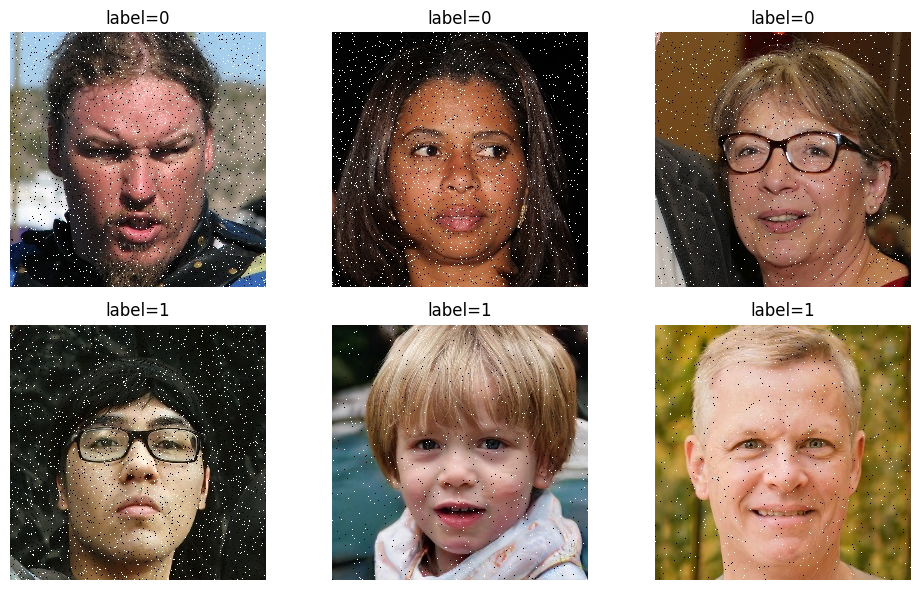

In [10]:
## Ячейка 1
df = pd.read_csv(cfg.labels_path, header=None, names=["id", "label"])

df["image_path"] = df["id"].astype(str).apply(lambda x: cfg.train_dir / f"{x}.jpg")
print(df["label"].value_counts(normalize=True))

df_0 = df[df["label"] == 0].sample(3, random_state=cfg.seed)
df_1 = df[df["label"] == 1].sample(3, random_state=cfg.seed)
samples = pd.concat([df_0, df_1]).reset_index(drop=True)
plt.figure(figsize=(10, 6))

for i, row in samples.iterrows():
    img = Image.open(row["image_path"])
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"label={row['label']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
## Ячейка 2
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=kernel_size,
            stride=stride, padding=padding, groups=in_channels, bias=bias
        )
        self.pointwise = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=bias
        )
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return x
class XceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, reps=2, stride=1, grow_first=True):
        super().__init__()

        layers = []
        current_channels = in_channels

        if grow_first:
            layers.append(nn.ReLU())
            layers.append(SeparableConv2d(current_channels, out_channels, 3, 1, 1))
            current_channels = out_channels

            for _ in range(reps - 1):
                layers.append(nn.ReLU())
                layers.append(SeparableConv2d(current_channels, current_channels, 3, 1, 1))
        else:
            for _ in range(reps - 1):
                layers.append(nn.ReLU())
                layers.append(SeparableConv2d(current_channels, current_channels, 3, 1, 1))

            layers.append(nn.ReLU())
            layers.append(SeparableConv2d(current_channels, out_channels, 3, 1, 1))
            current_channels = out_channels

        if stride != 1:
            layers.append(nn.MaxPool2d(kernel_size=3, stride=stride, padding=1))

        self.block = nn.Sequential(*layers)

        self.skip = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        return self.block(x) + self.skip(x)
    
class SmallXception(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.block1 = XceptionBlock(64, 128, reps=2, stride=2, grow_first=True)
        self.block2 = XceptionBlock(128, 256, reps=2, stride=2, grow_first=True)
        self.block3 = XceptionBlock(256, 512, reps=2, stride=2, grow_first=True)

        self.middle = nn.Sequential(
            XceptionBlock(512, 512, reps=3, stride=1, grow_first=True),
            XceptionBlock(512, 512, reps=3, stride=1, grow_first=True),
            XceptionBlock(512, 512, reps=3, stride=1, grow_first=True),
        )
        self.exit = nn.Sequential(
            XceptionBlock(512, 768, reps=2, stride=2, grow_first=False),
            nn.ReLU(),
            SeparableConv2d(768, 1024, 3, 1, 1),
            nn.ReLU(),
            SeparableConv2d(1024, 1280, 3, 1, 1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(1280, 1)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.middle(x)
        x = self.exit(x)
        x = self.pool(x)
        x = self.fc(x)
        return x

In [12]:
## Ячейка 3
train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [13]:
## Ячейка 4
class SqueezeExcite(nn.Module):
    def __init__(self, channels, se_ratio=0.25):
        super().__init__()
        hidden = max(8, int(channels * se_ratio))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc1(scale)
        scale = F.silu(scale)
        scale = self.fc2(scale)
        scale = torch.sigmoid(scale)
        return x * scale


class MBConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, expand_ratio=4, se_ratio=0.25, drop_rate=0.0):
        super().__init__()

        self.use_residual = (stride == 1 and in_channels == out_channels)
        hidden_dim = in_channels * expand_ratio

        layers = []
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU(),
            ])
        else:
            hidden_dim = in_channels
        layers.extend([
            nn.Conv2d(
                hidden_dim, hidden_dim,
                kernel_size=3, stride=stride, padding=1,
                groups=hidden_dim, bias=False
            ),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(),
        ])

        self.pre_se = nn.Sequential(*layers)
        self.se = SqueezeExcite(hidden_dim, se_ratio=se_ratio)
        self.project = nn.Sequential(
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        self.drop = nn.Dropout2d(drop_rate) if drop_rate > 0 else nn.Identity()

    def forward(self, x):
        out = self.pre_se(x)
        out = self.se(out)
        out = self.project(out)

        if self.use_residual:
            out = self.drop(out)
            out = out + x

        return out


class SmallEfficientNet(nn.Module):
    def __init__(self, head_dropout=0.4):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.SiLU(),
        )

        self.blocks = nn.Sequential(
            MBConv(24, 24, stride=1, expand_ratio=1, drop_rate=0.00),
            MBConv(24, 40, stride=2, expand_ratio=4, drop_rate=0.00),
            MBConv(40, 40, stride=1, expand_ratio=4, drop_rate=0.02),
            MBConv(40, 64, stride=2, expand_ratio=4, drop_rate=0.02),
            MBConv(64, 64, stride=1, expand_ratio=4, drop_rate=0.04),
            MBConv(64, 96, stride=2, expand_ratio=4, drop_rate=0.04),
            MBConv(96, 96, stride=1, expand_ratio=4, drop_rate=0.06),
            MBConv(96, 160, stride=2, expand_ratio=6, drop_rate=0.06),
            MBConv(160, 160, stride=1, expand_ratio=6, drop_rate=0.08),
        )

        self.head_conv = nn.Sequential(
            nn.Conv2d(160, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.SiLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(head_dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head_conv(x)
        x = self.pool(x)
        x = self.head(x)
        return x

### 8. Воспроизводимость
Этот код создает финальный submission из использованных моделей

In [14]:
# Путь до артефактов
pred_dir = Path("artifacts_ensemble/predictions")
# Использующиеся модели
run_names = [
    "xception_affine_seed42",
    "xception_affine_seed43",
    "xception_affine_seed44",
    "efficient_affine_seed42",
    "efficient_affine_seed43",
    "efficient_affine_seed44",
]

# 1. Загрузка данных о предсказаниях на валидации
val_features = []
val_targets = None

for run in run_names:
    probs = np.load(pred_dir / f"{run}_val_probs.npy")
    targets = np.load(pred_dir / f"{run}_val_targets.npy")
    val_targets = targets
    val_features.append(probs)
X_val = np.stack(val_features, axis=1)

# 2. Обучение модели-"голосующего"
model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
)

model.fit(X_val, val_targets)

# 3. Поиск лучшего порога
val_preds = model.predict_proba(X_val)[:, 1]

best_thr = 0
best_f1 = 0

for t in np.linspace(0.01, 0.99, 200):
    f1 = f1_score(val_targets, val_preds > t)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

print(f"Лучший F1-score: {best_f1:.4f}")

# 4. Загрузка тестовых предсказаний
test_features = []
test_ids = None

for run in run_names:
    df = pd.read_csv(pred_dir / f"{run}_test_probs.csv")
    df = df.sort_values("id").reset_index(drop=True)
    test_ids = df["id"]
    test_features.append(df["prob"].values)

X_test = np.stack(test_features, axis=1)

# 5. Финальное предсказание
test_preds = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "id": test_ids,
    "target_feature": (test_preds > best_thr).astype(int)
})

submission.to_csv("submission_lgbm.csv", index=False)

[LightGBM] [Info] Number of positive: 1700, number of negative: 8300
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1524
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.170000 -> initscore=-1.585627
[LightGBM] [Info] Start training from score -1.585627
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

c:\Users\pocht\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Лучший F1-score: 0.9920


c:\Users\pocht\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
